# Retail Sales Data Analytic: Exploratory Data Analysis

## Project Overview

## Document Purpose

* Which countries generate the most revenue?
* Which product generate most revenue?
* Product Qauntity vs Revenue
* How many times are the customer buying?
* Top and Bottom 10 Products Contributing to Sale Revenue.
* Understand overall customer purchasing behaviour in terms of RFM

## Setup 

Before beginning the exploratory data analysis (EDA), we’ll load and prepare the cleaned dataset for analysis and visualization.

In [47]:
# modules we'll use
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# set defualt setting
sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13
ACCENT = "#2E5C8A"
ACCENT2 = "#E8813A"

def money(x, pos=None):
    """Formatter for currency axis labels ($1.2K, $3.4M ...)."""
    if abs(x) >= 1_000_000:
        return f"${x/1_000_000:.1f}M"
    if abs(x) >= 1_000:
        return f"${x/1_000:.0f}K"
    return f"${x:.0f}"

# set project root
project_root = os.getcwd()
if os.path.basename(project_root) == "noteboook":
    project_root = os.path.dirname(project_root)

file_path = os.path.join(project_root, "data", "cleaned", "cleaned_retail_sales.xlsx")

try:
    df = pd.read_excel(file_path)
except ImportError as error:
    raise ImportError("Install openpyxl first: pip install openpyxl") from error

df["invoice_no"] = df["invoice_no"].astype(str)
df["is_cancelled"] = df["invoice_no"].str.startswith("C")

sales = df[(~df["is_cancelled"]) & (df["quantity"] > 0) & (df["unit_price"] > 0)].copy()
sales["sales_revenue"] = sales["quantity"] * sales["unit_price"]
sales["year_month"] = sales["invoice_date"].dt.to_period("M")
sales["month_name"] = sales["invoice_date"].dt.strftime("%b")
# set seed for reproducibility
np.random.seed(0)

# preview 10 rows of cleaned dataset
df.head(10)

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,is_cancelled
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom,False
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom,False
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,False
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,False
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom,False


## 1. Which product generate the highest total revenue?

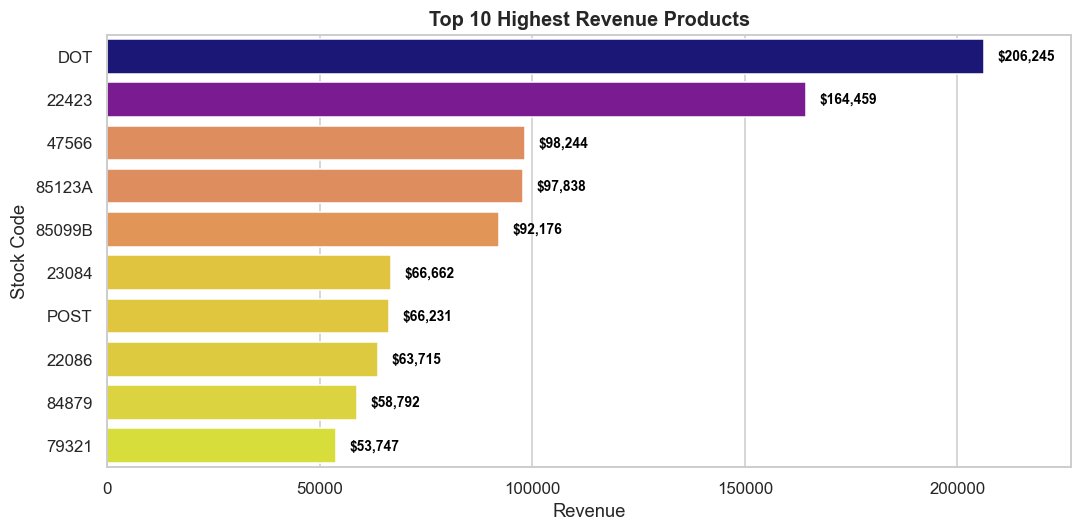

In [50]:
df['total_revenue'] = df['unit_price'] * df['quantity']
high_rev_prod = df.groupby('stock_code')['total_revenue'].sum().reset_index().sort_values(by='total_revenue', ascending=False).head(10)

fig, axes = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=high_rev_prod,
    x='total_revenue',
    y='stock_code',
    hue='total_revenue',
    palette='plasma_r',
    legend=False,
    ax=axes,
)

for patch in axes.patches:
    width = patch.get_width()
    if width > 0:
        axes.text(
            x=width + (axes.get_xlim()[1] * 0.015),       
            y=patch.get_y() + patch.get_height() / 2,     
            s=f"${width:,.0f}",                           
            ha='left', 
            va='center', 
            fontsize=9, 
            fontweight='semibold',
            color="#000000"
        )

axes.margins(x=0.10)

plt.title("Top 10 Highest Revenue Products")
plt.xlabel('Revenue')
plt.ylabel('Stock Code')

plt.tight_layout()
plt.show()

## 2. Which Country Generate The Most Revenue? (Excluding United Kingdom)

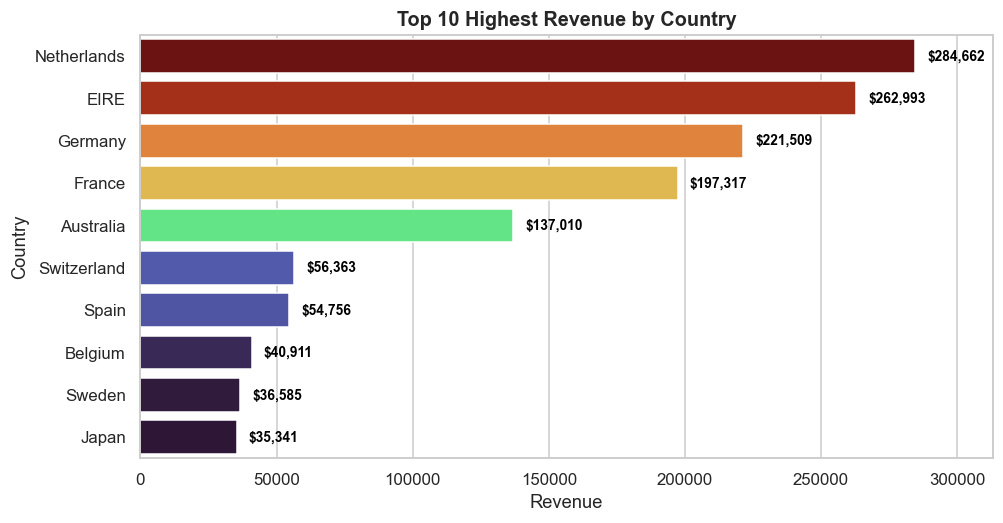

In [51]:
df_exclude_uk = df.copy()
df_exclude_uk = df_exclude_uk[df_exclude_uk['country'] != 'United Kingdom']
top_country = df_exclude_uk.groupby('country')['total_revenue'].sum().reset_index().sort_values(by='total_revenue', ascending=False).head(10)

fig, axes = plt.subplots(figsize=(10,5))

sns.barplot(
    data=top_country,
    x='total_revenue',
    y='country',
    hue='total_revenue',
    palette='turbo',
    legend=False,
    ax=axes,
)

for patch in axes.patches:
    width = patch.get_width()
    if width > 0:
        axes.text(
            x=width + (axes.get_xlim()[1] * 0.015),       
            y=patch.get_y() + patch.get_height() / 2,     
            s=f"${width:,.0f}",                           
            ha='left', 
            va='center', 
            fontsize=9, 
            fontweight='semibold',
            color="#000000"
        )

axes.margins(x=0.10)

plt.title("Top 10 Highest Revenue by Country")
plt.xlabel('Revenue')
plt.ylabel('Country')

plt.tight_layout
plt.show()